# Project 3 – Transportation Data Analysis and IDM Simulation

## Project Overview
This project analyzes transportation trends and driving behavior using two datasets: the National Household Travel Survey (NHTS) and the Next Generation Simulation (NGSIM) dataset.

The NHTS dataset provides information about household travel characteristics, while the NGSIM dataset provides detailed vehicle trajectory data. The project includes data visualization and a simulation study using the Intelligent Driver Model (IDM).

---

## Objectives
- Create visualizations to identify transportation trends
- Analyze driving behavior using time-series data
- Simulate vehicle following behavior using the IDM model
- Compare simulated results with real trajectory data

---

## Data Used
- **NHTS.csv** – household travel data
- **NGSIM.csv** – vehicle trajectory and driving behavior data

---

## Visualizations Included
- Bar chart: fuel type distribution
- Histogram: household size distribution
- Boxplot: vehicle age by household location
- Time-series plots:
  - Follower speed vs time
  - Leader and follower position vs time
  - Gap distance vs time (extra analysis)

---

## Simulation Study (IDM)
The Intelligent Driver Model (IDM) is used to simulate follower vehicle behavior.

- Leader vehicle data is used as input
- Initial follower conditions are taken from real data
- Acceleration is calculated using IDM equations
- Speed and position are updated over time
- Simulated results are compared with actual data

---

## Tools and Libraries
- pandas
- numpy
- matplotlib
- seaborn

---

## User Guide
1. Open the Jupyter Notebook file: CIVE202_Spring2026_Project3_Group8_PythonCode
2. Make sure the following files are in the same folder:
- NHTS.csv
- NGSIM.csv
3. Run all cells in order from top to bottom.
4. The notebook will:
- load the datasets
- create all required plots
- run the IDM simulation
- display results and comparisons



---

## Summary
The results show clear transportation trends in the NHTS dataset and realistic driving behavior in the NGSIM dataset. The IDM simulation produces similar patterns to the actual data, demonstrating the ability of the model to represent vehicle following behavior.

## Data Loading and Setup

The required Python libraries are imported, including pandas, numpy, matplotlib, and seaborn. These libraries are used for data processing and visualization.

A visual style is applied using seaborn to improve the appearance of plots. The NHTS and NGSIM datasets are then loaded into the notebook using the read_csv() function.

These datasets provide the data needed for transportation analysis and simulation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('deep')

nhts_data = pd.read_csv('NHTS.csv')
ngsim_data = pd.read_csv('NGSIM.csv')

## Bar Chart – Fuel Type Distribution

The bar chart uses the fuel_type variable from the NHTS dataset. The value_counts() function is used to count how many vehicles fall into each fuel category. The dropna() function removes any missing values from the result.

The plot shows the number of vehicles for each fuel type. Gas vehicles have the highest count, while alternative fuel types such as electric and biodiesel have lower counts.

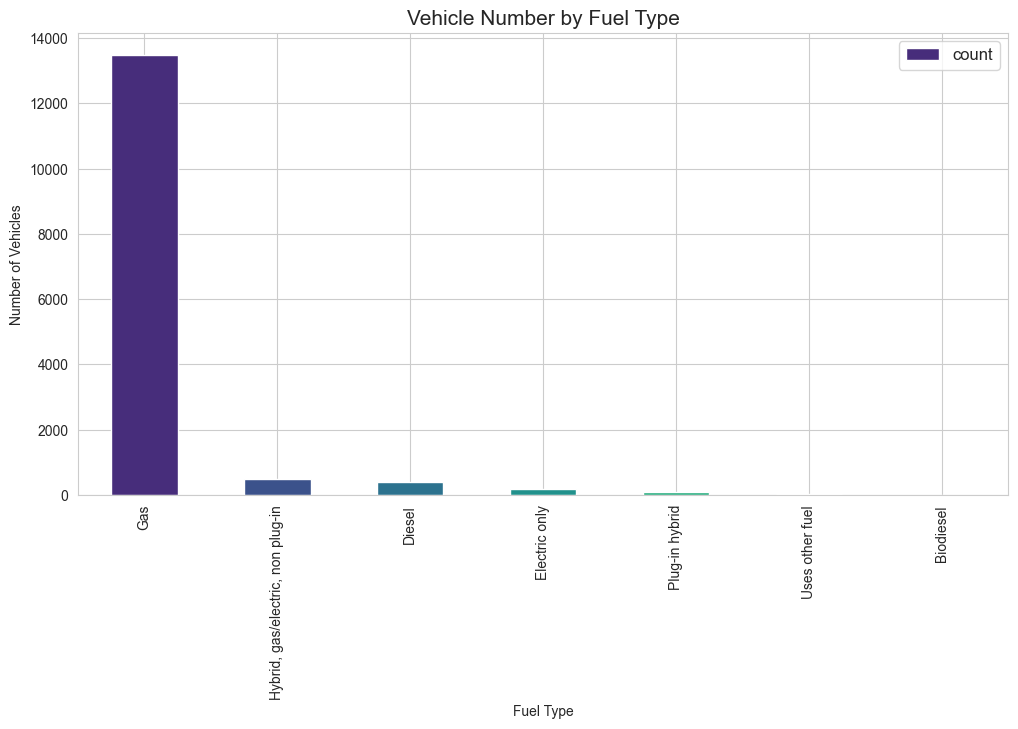

In [3]:
#bar chart
fuel_counts = nhts_data['fuel_type'].value_counts().dropna()
plt.figure(figsize = (12,6))
fuel_counts.plot(kind = 'bar', color = sns.color_palette('viridis',len(fuel_counts)))

plt.xlabel('Fuel Type')
plt.ylabel('Number of Vehicles')
plt.title('Vehicle Number by Fuel Type', fontsize = 15)
plt.xticks()
plt.legend(fontsize = 12)

plt.show()

## Histogram – Acceleration Distribution

The histogram uses the leader_acc(m/s^2) and follower_acc(m/s^2) variables from the NGSIM dataset. The plot shows the distribution of acceleration values for both leader and follower vehicles.

The histplot function is used to display the frequency of acceleration values, while the KDE curve provides a smooth representation of the distribution. Two datasets are plotted together to allow comparison between leader and follower behavior.

The results show that most acceleration values are concentrated near zero, indicating steady driving conditions. Larger positive and negative values occur less frequently, representing acceleration and braking events.

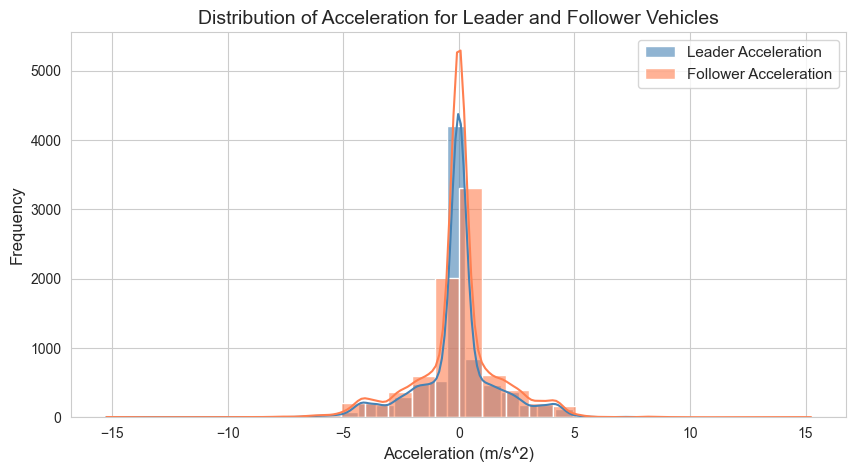

In [4]:
#histogram
plt.figure(figsize = (10,5))
sns.histplot(ngsim_data['leader_acc(m/s^2)'], bins = 30, kde = True, label = 'Leader Acceleration', color = 'steelblue', alpha = 0.6)
sns.histplot(ngsim_data['follower_acc(m/s^2)'], bins = 30, kde = True, label = 'Follower Acceleration', color = 'coral', alpha = 0.6)
plt.xlabel('Acceleration (m/s^2)', fontsize = 12)
plt.ylabel('Frequency', fontsize = 12)
plt.title('Distribution of Acceleration for Leader and Follower Vehicles', fontsize = 14)
plt.legend(fontsize = 11)
plt.show()

## Boxplot – Vehicle Age by Make

The boxplot uses the vehicle_age variable grouped by make from the NHTS dataset. The boxplot function is used to display the distribution of vehicle age for each vehicle make.

Each box represents the interquartile range, with the line inside the box showing the median vehicle age. The whiskers represent the range of the data, and points outside the whiskers are outliers.

The plot shows variation in vehicle age across different vehicle makes. Some makes have higher median vehicle age and larger spread, indicating differences in vehicle usage and ownership patterns.

<Figure size 1000x500 with 0 Axes>

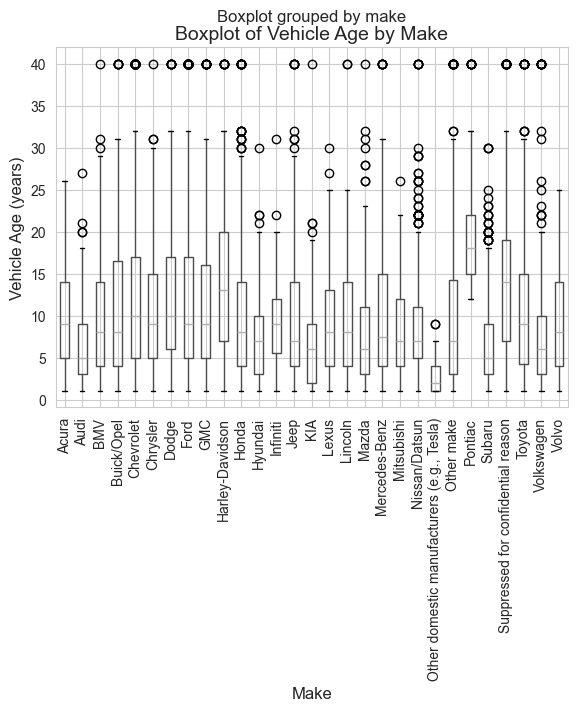

<Figure size 640x480 with 0 Axes>

In [5]:
#box plot
plt.figure(figsize = (10,5))
boxplot = nhts_data.boxplot(column = 'vehicle_age', by = 'make')

plt.xticks(rotation = 90)
plt.xlabel('Make', fontsize = 12)
plt.ylabel('Vehicle Age (years)', fontsize = 12)
plt.title('Boxplot of Vehicle Age by Make', fontsize = 14)

plt.show()
plt.savefig("my_boxplot.png", dpi = 300, bbox_inches="tight")

## Time-Series Dashboard – Vehicle Pair Analysis

The dashboard uses data from a selected trajectory in the NGSIM dataset. A subset of the data is created using a specific trajectory number. The gap distance is calculated as the difference between leader and follower positions.

Four time-series plots are created to analyze vehicle behavior. The first plot shows position over time for both leader and follower vehicles. The second plot shows speed over time. The third plot shows acceleration over time. The fourth plot shows gap distance over time.

The plots illustrate how the follower vehicle responds to the leader vehicle. Similar patterns in position and speed indicate consistent vehicle following behavior. Variations in acceleration show periods of speeding up and slowing down. Changes in gap distance reflect traffic conditions and spacing between vehicles.

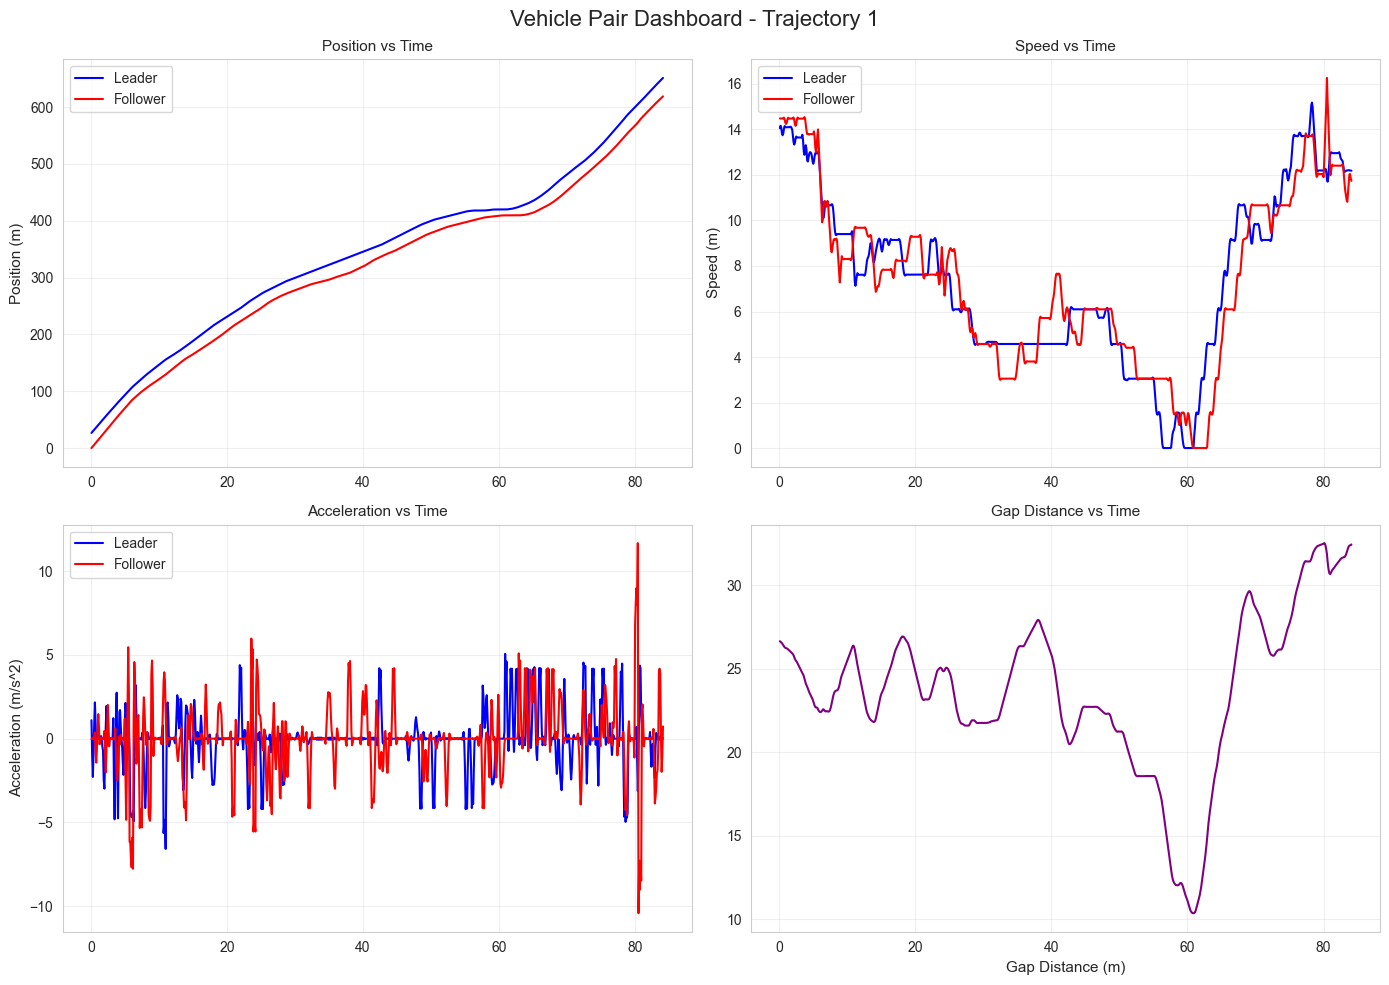

In [6]:
#time series charts
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time = data_subset['Time'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Position vs. Time
axes[0,0].plot(time, data_subset['leader_position(m)'].values, 'b-', label = 'Leader', linewidth = 1.5)
axes[0,0].plot(time, data_subset['follower_position(m)'].values, 'r-', label = 'Follower', linewidth = 1.5)
axes[0,0].set_ylabel('Position (m)', fontsize = 11)
axes[0,0].set_title('Position vs Time', fontsize = 11)
axes[0,0].legend(fontsize = 10)
axes[0,0].grid(True, alpha = 0.3)

#Speed vs. Time
axes[0,1].plot(time, data_subset['leader_speed(m/s)'].values, 'b-', label = 'Leader', linewidth = 1.5)
axes[0,1].plot(time, data_subset['follower_speed(m/s)'].values, 'r-', label = 'Follower', linewidth = 1.5)
axes[0,1].set_ylabel('Speed (m)', fontsize = 11)
axes[0,1].set_title('Speed vs Time', fontsize = 11)
axes[0,1].legend(fontsize = 10)
axes[0,1].grid(True, alpha = 0.3)

#Acceleration vs Time
axes[1,0].plot(time, data_subset['leader_acc(m/s^2)'].values, 'b-', label = 'Leader', linewidth = 1.5)
axes[1,0].plot(time, data_subset['follower_acc(m/s^2)'].values, 'r-', label = 'Follower', linewidth = 1.5)
axes[1,0].set_ylabel('Acceleration (m/s^2)', fontsize = 11)
axes[1,0].set_title('Acceleration vs Time', fontsize = 11)
axes[1,0].legend(fontsize = 10)
axes[1,0].grid(True, alpha = 0.3)

#Distance vs Time
axes[1,1].plot(time, gap, 'purple', linewidth = 1.5)
axes[1,1].set_xlabel('Time (seconds)', fontsize = 11)
axes[1,1].set_xlabel('Gap Distance (m)', fontsize = 11)
axes[1,1].set_title('Gap Distance vs Time', fontsize = 11)
axes[1,1].grid(True, alpha = 0.3)

plt.suptitle(f'Vehicle Pair Dashboard - Trajectory {trajectory_number}', fontsize = 16)
plt.tight_layout()
plt.show()

## IDM Simulation – Model Setup

The simulation uses trajectory data from the NGSIM dataset. A subset of the data is selected using a specific trajectory number. Time, leader position, and leader speed are extracted from the dataset.

Model parameters are defined, including desired speed, minimum gap distance, time headway, maximum acceleration, comfortable deceleration, and acceleration exponent. These parameters control vehicle following behavior in the Intelligent Driver Model (IDM).

Arrays are created to store simulated position, speed, and acceleration values. Initial conditions for the follower vehicle are taken from the first data point.

In [9]:
#simulation
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    s_star = max(s_star, s0)
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    return acceleration

In [10]:
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)

time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values
dt = 0.1

v0 = 30
s0 = 2
T = 1.5
a_param = 1.0
b = 1.5
delta = 4

n_steps = len(time_data)
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acc = np.zeros(n_steps)
#print(n_steps)
#print(sim_speed)

sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]

## IDM Simulation – Model Implementation

The IDM function calculates acceleration based on current speed, gap distance, and relative speed between vehicles. Desired spacing is computed using the model equation.

A loop is used to update the follower vehicle behavior at each time step. Gap distance is calculated as the difference between leader and follower positions. Acceleration is used to update speed, and speed is used to update position.

This process repeats for all time steps to simulate vehicle motion.

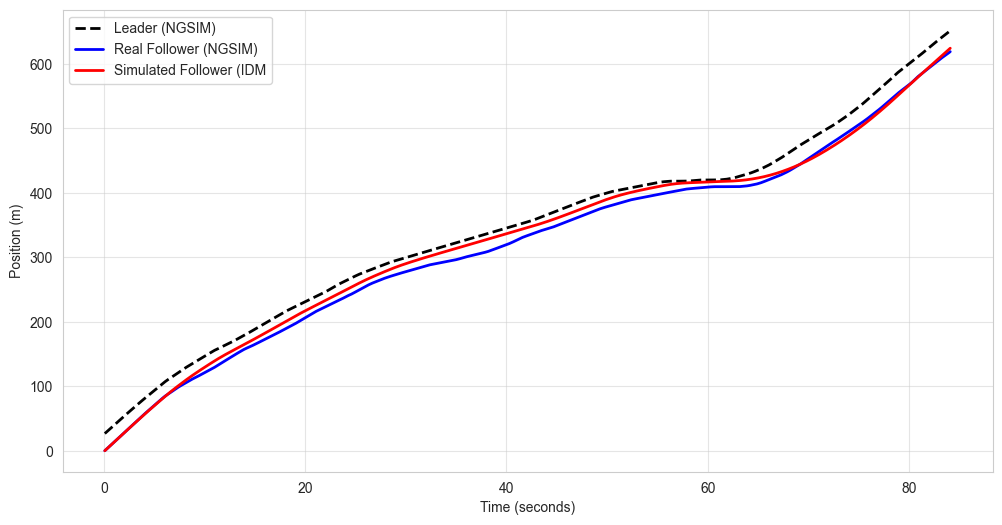

In [11]:
for i in range(n_steps - 1):
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]
    
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)
    
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i]*dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt
  
#print("Simulation complete!")

plt.figure(figsize = (12,6))
plt.plot(time_data, leader_position, 'k--', linewidth = 2, label = 'Leader (NGSIM)')
plt.plot(time_data, data_subset['follower_position(m)'].values, 'b-', linewidth = 2, label = 'Real Follower (NGSIM)')
plt.plot(time_data, sim_position, 'r-', linewidth = 2, label = 'Simulated Follower (IDM')
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

## IDM Simulation – Results and Comparison

The plot compares leader position, actual follower position, and simulated follower position over time. The simulated results follow similar trends as the real data.

The model captures general vehicle following behavior, including acceleration and deceleration patterns. Small differences are present due to simplified assumptions in the model.

The results demonstrate that the IDM can represent vehicle following behavior under real traffic conditions.